In [11]:
import baostock as bs
import pandas as pd

# 登陆系统
lg = bs.login()
# 显示登陆返回信息
print('login respond error_code:'+lg.error_code)
print('login respond  error_msg:'+lg.error_msg)



login success!
login respond error_code:0
login respond  error_msg:success


In [5]:
'''
查询特定季频估值指标盈利能力
'''
# profit_list = []
# rs_profit = bs.query_profit_data(src="sh.600000", year=2017, quarter=2)
# while (rs_profit.error_code == '0') & rs_profit.next():
#   profit_list.append(rs_profit.get_row_data())
# result_profit = pd.DataFrame(profit_list, columns=rs_profit.fields)
# result_profit.tail(10)
# # 打印输出
# # print(result_profit)
# # 结果集输出到csv文件
# # result_profit.to_csv("D:\\profit_data.csv", encoding="gbk", index=False)
#
# # 登出系统
# # bs.logout()

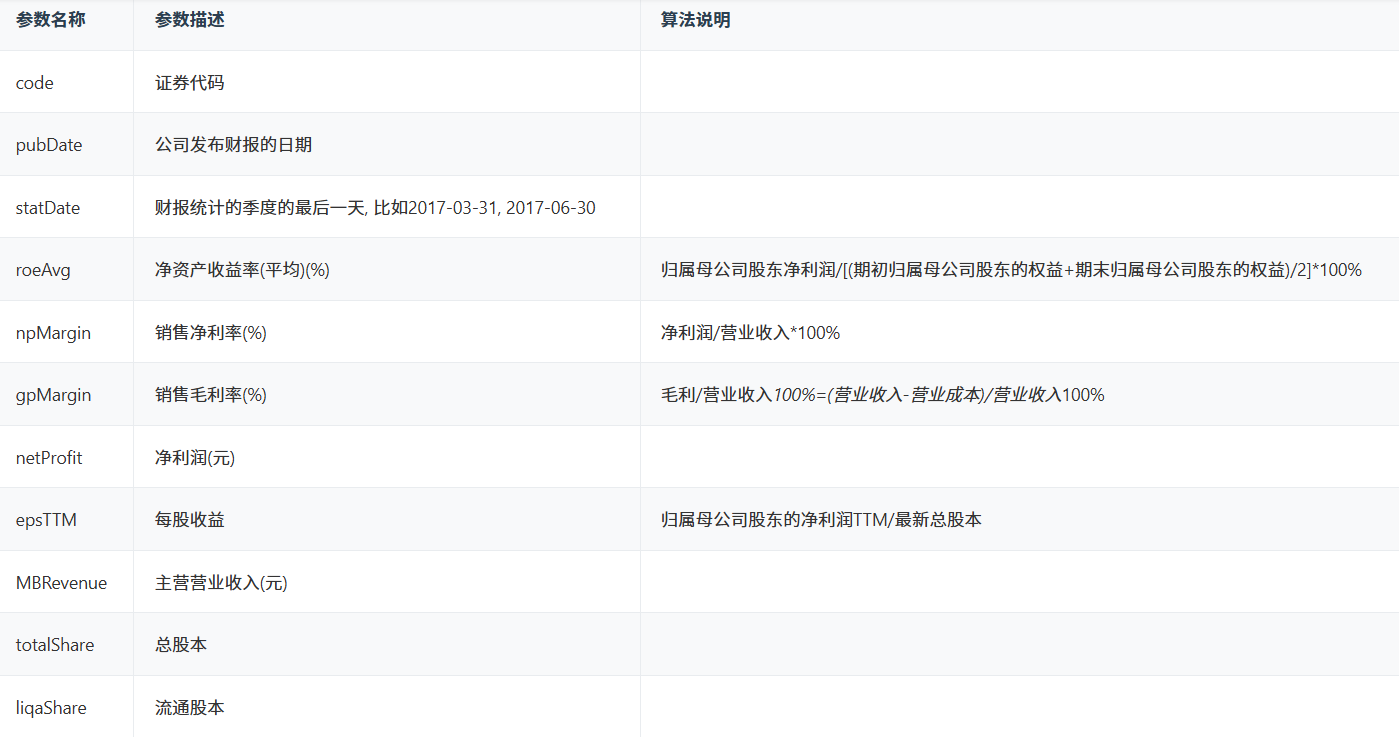

In [12]:

from datetime import datetime
from tqdm import tqdm  # 添加进度条库


# 初始化列表
all_profit_list = []

# 设置查询的起始年份和季度
start_year = 2020
start_quarter = 1

# 获取当前日期，以确定结束季度
now = datetime.now()
current_year = now.year
current_quarter = (now.month - 1) // 3 + 1

# 计算需要查询的总季度数
total_quarters = 0
for year in range(start_year, current_year + 1):
    quarter_start = start_quarter if year == start_year else 1
    quarter_end = current_quarter if year == current_year else 4
    total_quarters += (quarter_end - quarter_start + 1)

print(f"开始查询数据，共 {total_quarters} 个季度...")

# 使用tqdm创建单个进度条
progress_bar = tqdm(total=total_quarters, desc="查询进度", bar_format="{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]")

# 循环查询从2020年Q1到当前季度的数据
for year in range(start_year, current_year + 1):
    # 确定每一年需要查询的季度范围
    quarter_start = start_quarter if year == start_year else 1
    quarter_end = current_quarter if year == current_year else 4

    for quarter in range(quarter_start, quarter_end + 1):
        # 查询数据
        rs_profit = bs.query_profit_data(code="sh.600000", year=year, quarter=quarter)

        if rs_profit.error_code != '0':
            # 如果查询出错，更新进度条但跳过
            progress_bar.update(1)
            continue

        # 将当季数据添加到列表
        while rs_profit.next():
            all_profit_list.append(rs_profit.get_row_data())

        # 更新进度条
        progress_bar.update(1)

# 关闭进度条
progress_bar.close()

# 将结果转换为DataFrame
if all_profit_list:
    result_profit = pd.DataFrame(all_profit_list, columns=rs_profit.fields)

    # 打印输出
    print(f"\n✓ 数据查询完成！")
    print(f"✓ 共获取到 {len(result_profit)} 条季度盈利数据")
    print(f"✓ 时间范围: {start_year}年Q{start_quarter} - {current_year}年Q{current_quarter}")

    # 显示最新5条数据
    print("\n最新10条数据:")
    print(result_profit.tail(10))
    #
    # # # 结果集输出到csv文件
    # result_profit.to_csv("F:\\self_quant\\data_test\\notebook\\profit_data_2020_to_present.csv", encoding="gbk", index=False)
    # print(f"\n✓ 数据已成功保存至: F:\\self_quant\\data_test\\notebook\\profit_data_2020_to_present.csv")
else:
    print("⚠ 未获取到任何数据。")

# # 登出系统
# bs.logout()

<>:68: SyntaxWarning: invalid escape sequence '\s'
<>:68: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Royin\AppData\Local\Temp\ipykernel_9712\2428477643.py:68: SyntaxWarning: invalid escape sequence '\s'
  result_profit.to_csv("F:\self_quant\data\data\\profit_data_2020_to_present.csv", encoding="gbk", index=False)


开始查询数据，共 25 个季度...


查询进度: 100%|██████████| 25/25 [00:08<00:00,  2.80it/s]



✓ 数据查询完成！
✓ 共获取到 23 条季度盈利数据
✓ 时间范围: 2020年Q1 - 2026年Q1

最新10条数据:
         code     pubDate    statDate    roeAvg  npMargin gpMargin  \
13  sh.600000  2023-08-31  2023-06-30  0.032797  0.258851            
14  sh.600000  2023-10-28  2023-09-30  0.039596  0.215277            
15  sh.600000  2024-04-30  2023-12-31  0.051598  0.215811            
16  sh.600000  2024-04-30  2024-03-31  0.023738  0.389605            
17  sh.600000  2024-08-20  2024-06-30  0.036712  0.309627            
18  sh.600000  2024-10-31  2024-09-30  0.048669  0.274856            
19  sh.600000  2025-03-29  2024-12-31  0.061950  0.268437            
20  sh.600000  2025-04-30  2025-03-31  0.023725  0.387091            
21  sh.600000  2025-08-28  2025-06-30  0.038893  0.330105            
22  sh.600000  2025-10-31  2025-09-30  0.049494  0.296122            

             netProfit    epsTTM            MBRevenue      totalShare  \
13  23615000000.000000  1.503636  167814000000.000000  29352175421.00   
14  28592000000.00

In [15]:
import baostock as bs
import pandas as pd
from datetime import datetime
from tqdm import tqdm  # 添加进度条库

def get_stock_profit_data(stock_code, start_date, end_date=None):
    """
    获取指定股票在指定时间范围内的季度盈利数据

    参数:
    stock_code (str): 股票代码，格式如 "sh.600000" 或 "sz.000001"
    start_date (str): 开始日期，格式为 "YYYY-MM-DD" 或 "YYYY-季度" 如 "2020-01-01" 或 "2020-Q1"
    end_date (str, optional): 结束日期，格式同start_date，默认为当前日期

    返回:
    pandas.DataFrame: 包含季度盈利数据的DataFrame
    """

    # 登陆系统
    print("正在连接Baostock数据源...")
    lg = bs.login()

    if lg.error_code != '0':
        print(f"登陆失败: {lg.error_msg}")
        return None

    # 初始化列表
    all_profit_list = []

    # 处理开始和结束时间
    try:
        # 解析开始日期
        if "-Q" in start_date:
            # 格式为 "2020-Q1"
            start_year, quarter_str = start_date.split("-Q")
            start_year = int(start_year)
            start_quarter = int(quarter_str)
        else:
            # 格式为 "2020-01-01"
            start_dt = datetime.strptime(start_date, "%Y-%m-%d")
            start_year = start_dt.year
            start_quarter = (start_dt.month - 1) // 3 + 1

        # 解析结束日期
        if end_date is None:
            # 默认为当前日期
            now = datetime.now()
            end_year = now.year
            end_quarter = (now.month - 1) // 3 + 1
        elif "-Q" in end_date:
            # 格式为 "2023-Q4"
            end_year, quarter_str = end_date.split("-Q")
            end_year = int(end_year)
            end_quarter = int(quarter_str)
        else:
            # 格式为 "2023-12-31"
            end_dt = datetime.strptime(end_date, "%Y-%m-%d")
            end_year = end_dt.year
            end_quarter = (end_dt.month - 1) // 3 + 1

    except ValueError as e:
        print(f"日期格式错误: {e}")
        print("请使用格式: 'YYYY-MM-DD' 或 'YYYY-QX' (X为1-4)")
        bs.logout()
        return None

    # 验证季度范围
    if not (1 <= start_quarter <= 4) or not (1 <= end_quarter <= 4):
        print("季度参数错误: 季度必须是1-4之间的整数")
        bs.logout()
        return None

    # 计算需要查询的总季度数
    total_quarters = 0
    quarter_list = []  # 存储要查询的所有季度

    for year in range(start_year, end_year + 1):
        # 确定每一年需要查询的季度范围
        quarter_start = start_quarter if year == start_year else 1
        quarter_end = end_quarter if year == end_year else 4

        for quarter in range(quarter_start, quarter_end + 1):
            total_quarters += 1
            quarter_list.append((year, quarter))

    if total_quarters == 0:
        print("没有找到要查询的季度数据")
        bs.logout()
        return None

    print(f"开始查询 {stock_code} 的季度盈利数据...")
    print(f"时间范围: {start_year}年Q{start_quarter} - {end_year}年Q{end_quarter}")
    print(f"共 {total_quarters} 个季度")

    # 使用tqdm创建进度条
    progress_bar = tqdm(total=total_quarters, desc="查询进度",
                       bar_format="{desc}: {percentage:3.0f}%|{bar}| {n_fmt}/{total_fmt} 季度")

    # 循环查询每个季度的数据
    for year, quarter in quarter_list:
        # 查询数据
        rs_profit = bs.query_profit_data(code=stock_code, year=year, quarter=quarter)

        if rs_profit.error_code != '0':
            # 如果查询出错，记录日志但继续
            pass
        else:
            # 将当季数据添加到列表
            while rs_profit.next():
                all_profit_list.append(rs_profit.get_row_data())

        # 更新进度条
        progress_bar.update(1)

    # 关闭进度条
    progress_bar.close()

    # 登出系统
    bs.logout()

    # 将结果转换为DataFrame
    if all_profit_list:
        result_profit = pd.DataFrame(all_profit_list, columns=rs_profit.fields)



        # 按日期排序
        if 'statDate' in result_profit.columns:
            result_profit = result_profit.sort_values('statDate')

        print(f"\n✓ 数据查询完成！")
        print(f"✓ 共获取到 {len(result_profit)} 条季度盈利数据")

        return result_profit
    else:
        print("⚠ 未获取到任何数据。")
        return None

'''
# 使用示例
if __name__ == "__main__":
    # 示例1: 使用默认结束时间（当前时间）
    result1 = get_stock_profit_data(
        stock_code="sh.600000",  # 浦发银行
        start_date="2020-01-01"  # 从2020年1月1日开始
    )

    if result1 is not None:
        print("\n前5条数据:")
        print(result1.head())
        # 保存到CSV
        result1.to_csv("D:\\浦发银行_盈利数据.csv", encoding="gbk", index=False)

    print("\n" + "="*50 + "\n")

    # 示例2: 指定开始和结束时间
    result2 = get_stock_profit_data(
        stock_code="sz.000001",  # 平安银行
        start_date="2020-Q1",     # 从2020年第一季度开始
        end_date="2023-Q4"        # 到2023年第四季度结束
    )

    if result2 is not None:
        print("\n前5条数据:")
        print(result2.head())
        # 保存到CSV
        result2.to_csv("D:\\平安银行_盈利数据.csv", encoding="gbk", index=False)

    print("\n" + "="*50 + "\n")

    # 示例3: 查询指定日期范围
    result3 = get_stock_profit_data(
        stock_code="sh.601318",  # 中国平安
        start_date="2021-07-01",  # 从2021年7月1日开始
        end_date="2024-12-31"     # 到2024年12月31日结束
    )

    if result3 is not None:
        print("\n前5条数据:")
        print(result3.head())
        # 保存到CSV
        result3.to_csv("D:\\中国平安_盈利数据.csv", encoding="gbk", index=False)
'''

'\n# 使用示例\nif __name__ == "__main__":\n    # 示例1: 使用默认结束时间（当前时间）\n    result1 = get_stock_profit_data(\n        stock_code="sh.600000",  # 浦发银行\n        start_date="2020-01-01"  # 从2020年1月1日开始\n    )\n\n    if result1 is not None:\n        print("\n前5条数据:")\n        print(result1.head())\n        # 保存到CSV\n        result1.to_csv("D:\\浦发银行_盈利数据.csv", encoding="gbk", index=False)\n\n    print("\n" + "="*50 + "\n")\n\n    # 示例2: 指定开始和结束时间\n    result2 = get_stock_profit_data(\n        stock_code="sz.000001",  # 平安银行\n        start_date="2020-Q1",     # 从2020年第一季度开始\n        end_date="2023-Q4"        # 到2023年第四季度结束\n    )\n\n    if result2 is not None:\n        print("\n前5条数据:")\n        print(result2.head())\n        # 保存到CSV\n        result2.to_csv("D:\\平安银行_盈利数据.csv", encoding="gbk", index=False)\n\n    print("\n" + "="*50 + "\n")\n\n    # 示例3: 查询指定日期范围\n    result3 = get_stock_profit_data(\n        stock_code="sh.601318",  # 中国平安\n        start_date="2021-07-01",  # 从2021年7月1日开始\n     

In [17]:

# 使用示例
if __name__ == "__main__":
    # # 示例1: 使用默认结束时间（当前时间）
    # result1 = get_stock_profit_data(
    #     stock_code="sh.600000",  # 浦发银行
    #     start_date="2020-01-01"  # 从2020年1月1日开始
    # )
    #
    # if result1 is not None:
    #     print("\n前5条数据:")
    #     print(result1.head())
    #     # 保存到CSV
    #     result1.to_csv("D:\\浦发银行_盈利数据.csv", encoding="gbk", index=False)
    #
    # print("\n" + "="*50 + "\n")
    #
    # # 示例2: 指定开始和结束时间
    # result2 = get_stock_profit_data(
    #     stock_code="sz.000001",  # 平安银行
    #     start_date="2020-Q1",     # 从2020年第一季度开始
    #     end_date="2023-Q4"        # 到2023年第四季度结束
    # )
    #
    # if result2 is not None:
    #     print("\n前5条数据:")
    #     print(result2.head())
    #     # 保存到CSV
    #     result2.to_csv("D:\\平安银行_盈利数据.csv", encoding="gbk", index=False)
    #
    # print("\n" + "="*50 + "\n")
    #
    # 示例3: 查询指定日期范围
    result3 = get_stock_profit_data(
        stock_code="sh.601318",  # 中国平安
        start_date="2025-07-01",  # 从2025年7月1日开始
        end_date="2026-12-31"     # 到2026年12月31日结束
    )

    if result3 is not None:
        print("\n后10条数据:")
        print(result3.tail(10))
        # 保存到CSV
        result3.to_csv("F:\self_quant\data\data\\中国平安_盈利数据.csv", encoding="gbk", index=False)

<>:43: SyntaxWarning: invalid escape sequence '\s'
<>:43: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Royin\AppData\Local\Temp\ipykernel_9712\952428191.py:43: SyntaxWarning: invalid escape sequence '\s'
  result3.to_csv("F:\self_quant\data\data\\中国平安_盈利数据.csv", encoding="gbk", index=False)


正在连接Baostock数据源...
login success!
开始查询 sh.601318 的季度盈利数据...
时间范围: 2025年Q3 - 2026年Q4
共 6 个季度


查询进度: 100%|██████████| 6/6 季度


logout success!

✓ 数据查询完成！
✓ 共获取到 1 条季度盈利数据

后10条数据:
        code     pubDate    statDate    roeAvg  npMargin gpMargin  \
0  sh.601318  2025-10-29  2025-09-30  0.138753  0.186168            

             netProfit    epsTTM MBRevenue      totalShare       liqaShare  
0  155067000000.000000  7.747061            18107641995.00  10660065083.00  
